In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('train.csv')
df.head()


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [4]:
df.shape

(614, 13)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [6]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [7]:
(df.isnull().sum() / len(df)) * 100

Loan_ID              0.000000
Gender               2.117264
Married              0.488599
Dependents           2.442997
Education            0.000000
Self_Employed        5.211726
ApplicantIncome      0.000000
CoapplicantIncome    0.000000
LoanAmount           3.583062
Loan_Amount_Term     2.280130
Credit_History       8.143322
Property_Area        0.000000
Loan_Status          0.000000
dtype: float64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
print(df["Gender"].value_counts())
print(df["Married"].value_counts())
print(df["Dependents"].value_counts())
print(df["Self_Employed"].value_counts())
print(df["Loan_Amount_Term"].value_counts())
print(df["Credit_History"].value_counts())

Gender
Male      489
Female    112
Name: count, dtype: int64
Married
Yes    398
No     213
Name: count, dtype: int64
Dependents
0     345
1     102
2     101
3+     51
Name: count, dtype: int64
Self_Employed
No     500
Yes     82
Name: count, dtype: int64
Loan_Amount_Term
360.0    512
180.0     44
480.0     15
300.0     13
84.0       4
240.0      4
120.0      3
60.0       2
36.0       2
12.0       1
Name: count, dtype: int64
Credit_History
1.0    475
0.0     89
Name: count, dtype: int64


In [10]:
df["LoanAmount"].describe()

count    592.000000
mean     146.412162
std       85.587325
min        9.000000
25%      100.000000
50%      128.000000
75%      168.000000
max      700.000000
Name: LoanAmount, dtype: float64

In [11]:
df["LoanAmount"].fillna(df["LoanAmount"].median())

0      128.0
1      128.0
2       66.0
3      120.0
4      141.0
       ...  
609     71.0
610     40.0
611    253.0
612    187.0
613    133.0
Name: LoanAmount, Length: 614, dtype: float64

<Axes: >

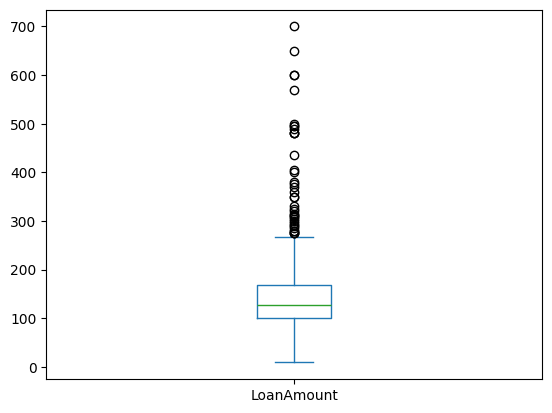

In [12]:
df["LoanAmount"].plot(kind="box")

In [13]:
df["LoanAmount"].fillna(df["LoanAmount"].median())

0      128.0
1      128.0
2       66.0
3      120.0
4      141.0
       ...  
609     71.0
610     40.0
611    253.0
612    187.0
613    133.0
Name: LoanAmount, Length: 614, dtype: float64

In [14]:
df["Gender"] = df["Gender"].fillna(df["Gender"].mode()[0])
df["Married"] = df["Married"].fillna(df["Married"].mode()[0])
df["Dependents"] = df["Dependents"].fillna(df["Dependents"].mode()[0])
df["Self_Employed"] = df["Self_Employed"].fillna(df["Self_Employed"].mode()[0])
df["Loan_Amount_Term"] = df["Loan_Amount_Term"].fillna(df["Loan_Amount_Term"].mode()[0])
df["Credit_History"] = df["Credit_History"].fillna(df["Credit_History"].mode()[0])

In [15]:
df["LoanAmount"] = df["LoanAmount"].fillna(df["LoanAmount"].median())

In [16]:
df.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [17]:
df.duplicated().sum()

np.int64(0)

In [18]:
df.drop("Loan_ID", axis=1, inplace=True)

In [19]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df["Gender"] = le.fit_transform(df["Gender"])
df["Married"] = le.fit_transform(df["Married"])
df["Education"] = le.fit_transform(df["Education"])
df["Self_Employed"] = le.fit_transform(df["Self_Employed"])
df["Loan_Status"] = le.fit_transform(df["Loan_Status"])
df = pd.get_dummies(df, columns=["Property_Area"], dtype=int)
df = pd.get_dummies(df, columns=["Dependents"], dtype=int)


In [20]:
df.corr()["Loan_Status"]

Gender                     0.017987
Married                    0.091478
Education                 -0.085884
Self_Employed             -0.003700
ApplicantIncome           -0.004710
CoapplicantIncome         -0.059187
LoanAmount                -0.033214
Loan_Amount_Term          -0.022549
Credit_History             0.540556
Loan_Status                1.000000
Property_Area_Rural       -0.100694
Property_Area_Semiurban    0.136540
Property_Area_Urban       -0.043621
Dependents_0              -0.003044
Dependents_1              -0.038740
Dependents_2               0.062384
Dependents_3+             -0.026123
Name: Loan_Status, dtype: float64

In [21]:
X = df.drop("Loan_Status", axis=1)
y = df["Loan_Status"]

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score,recall_score,f1_score,classification_report
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 42)
X_train.shape , X_test.shape

((491, 16), (123, 16))

In [23]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [24]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [25]:
np.round(X_train.describe(), 1)

,Gender,Married,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area_Rural,Property_Area_Semiurban,Property_Area_Urban,Dependents_0,Dependents_1,Dependents_2,Dependents_3+
count,491.0,491.0,491.0,491.0,491.0,491.0,491.0,491.0,491.0,491.0,491.0,491.0,491.0,491.0,491.0,491.0
mean,0.8,0.6,0.2,0.1,5502.6,1676.5,148.0,340.8,0.9,0.3,0.4,0.3,0.6,0.2,0.2,0.1
std,0.4,0.5,0.4,0.3,5933.0,3177.6,86.4,66.9,0.3,0.5,0.5,0.5,0.5,0.4,0.4,0.3
min,0.0,0.0,0.0,0.0,150.0,0.0,17.0,12.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,1.0,0.0,0.0,0.0,2918.5,0.0,102.5,360.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
50%,1.0,1.0,0.0,0.0,3900.0,1126.0,128.0,360.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
75%,1.0,1.0,0.0,0.0,5938.0,2333.0,165.0,360.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0
max,1.0,1.0,1.0,1.0,81000.0,41667.0,700.0,480.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [26]:
model = LogisticRegression()
model.fit(X_train,y_train)

y_pred = model.predict(X_test)
print("Accuracy score:",accuracy_score(y_test,y_pred))

y_pred1 = model.predict(X_train)
print("Accuracy score:",accuracy_score(y_train,y_pred1))

print("confusion matrix:",confusion_matrix(y_test,y_pred))
print("precision score:",precision_score(y_test,y_pred))
print("Recall score:", recall_score(y_test,y_pred))
print("f1 score:",f1_score(y_test,y_pred))
print("classification report",classification_report(y_test,y_pred))

Accuracy score: 0.7886178861788617
Accuracy score: 0.8167006109979633
confusion matrix: [[18 25]
 [ 1 79]]
precision score: 0.7596153846153846
Recall score: 0.9875
f1 score: 0.8586956521739131
classification report               precision    recall  f1-score   support

           0       0.95      0.42      0.58        43
           1       0.76      0.99      0.86        80

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.72       123
weighted avg       0.83      0.79      0.76       123



c:\Users\Tarun\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [27]:
X_train_scaled

,Gender,Married,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area_Rural,Property_Area_Semiurban,Property_Area_Urban,Dependents_0,Dependents_1,Dependents_2,Dependents_3+
0,0.483393,0.757442,-0.534173,-0.397516,0.083915,0.180667,1.355734,0.287611,0.407763,-0.63471,1.253268,-0.692037,0.822051,-0.43789,-0.434583,-0.301846
1,0.483393,0.757442,-0.534173,-0.397516,-0.429338,0.385430,-0.197609,0.287611,0.407763,-0.63471,1.253268,-0.692037,0.822051,-0.43789,-0.434583,-0.301846
2,0.483393,0.757442,-0.534173,-0.397516,0.126095,0.005831,0.718168,0.287611,0.407763,-0.63471,1.253268,-0.692037,-1.216469,-0.43789,2.301059,-0.301846
3,0.483393,0.757442,-0.534173,-0.397516,-0.576970,0.464185,-0.232385,0.287611,0.407763,-0.63471,1.253268,-0.692037,0.822051,-0.43789,-0.434583,-0.301846
4,0.483393,-1.320234,-0.534173,-0.397516,-0.225522,-0.528127,-0.580149,0.287611,-2.452404,-0.63471,1.253268,-0.692037,0.822051,-0.43789,-0.434583,-0.301846
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
486,0.483393,0.757442,1.872054,2.515623,-0.612064,0.062535,-0.591741,0.287611,0.407763,-0.63471,1.253268,-0.692037,-1.216469,-0.43789,2.301059,-0.301846
487,0.483393,0.757442,-0.534173,-0.397516,0.997882,-0.173415,0.892050,0.287611,0.407763,-0.63471,-0.797914,1.445009,-1.216469,-0.43789,2.301059,-0.301846
488,-2.068712,-1.320234,-0.534173,-0.397516,-0.382264,-0.528127,-1.368412,0.287611,0.407763,-0.63471,-0.797914,1.445009,0.822051,-0.43789,-0.434583,-0.301846
489,-2.068712,0.757442,-0.534173,-0.397516,0.766733,-0.528127,-0.232385,-1.506760,0.407763,-0.63471,1.253268,-0.692037,0.822051,-0.43789,-0.434583,-0.301846


In [50]:
y_prob = model.predict_proba(X_test)[:,1]

In [51]:
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

In [52]:
thresholds

array([       inf, 0.95960619, 0.90853976, 0.9045572 , 0.87962232,
       0.87692544, 0.87465265, 0.8683301 , 0.85794049, 0.85740795,
       0.83166342, 0.83130728, 0.82679779, 0.82511767, 0.82094685,
       0.81617212, 0.80459559, 0.8005694 , 0.79503753, 0.7913671 ,
       0.78987886, 0.78912011, 0.78551866, 0.78329808, 0.76914536,
       0.76721485, 0.76372795, 0.75741027, 0.73310526, 0.72896651,
       0.70503443, 0.68359739, 0.68343609, 0.67154426, 0.66838908,
       0.66200487, 0.65171827, 0.63972984, 0.54988146, 0.31665893,
       0.27845358, 0.0879482 ])

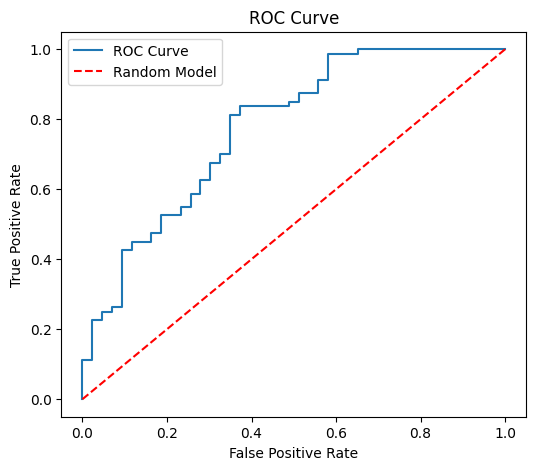

In [54]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label="ROC Curve")
plt.plot([0,1],[0,1],'r--',label="Random Model")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [55]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", auc)

ROC-AUC: 0.7747093023255814


In [56]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

for t in [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1]:

    y_pred = (y_prob >= t).astype(int)

    print(f"\nThreshold = {t}")
    print("Accuracy :", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall   :", recall_score(y_test, y_pred))


Threshold = 0.1
Accuracy : 0.6747967479674797
Precision: 0.6666666666666666
Recall   : 1.0

Threshold = 0.2
Accuracy : 0.7479674796747967
Precision: 0.7207207207207207
Recall   : 1.0

Threshold = 0.3
Accuracy : 0.7642276422764228
Precision: 0.7383177570093458
Recall   : 0.9875

Threshold = 0.4
Accuracy : 0.7804878048780488
Precision: 0.7523809523809524
Recall   : 0.9875

Threshold = 0.5
Accuracy : 0.7886178861788617
Precision: 0.7596153846153846
Recall   : 0.9875

Threshold = 0.6
Accuracy : 0.7642276422764228
Precision: 0.7524752475247525
Recall   : 0.95

Threshold = 0.7
Accuracy : 0.7560975609756098
Precision: 0.7976190476190477
Recall   : 0.8375

Threshold = 0.8
Accuracy : 0.6097560975609756
Precision: 0.8076923076923077
Recall   : 0.525

Threshold = 0.9
Accuracy : 0.43089430894308944
Precision: 0.9166666666666666
Recall   : 0.1375

Threshold = 1
Accuracy : 0.34959349593495936
Precision: 0.0
Recall   : 0.0


c:\Users\Tarun\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
